In [1]:
import networkx as nx
import matplotlib.pyplot as plt

### undirected graph

In [2]:
G = nx.Graph()

In [3]:
G.add_node('A')

G.nodes

NodeView(('A',))

In [4]:
G.add_nodes_from(['B','C','D'])

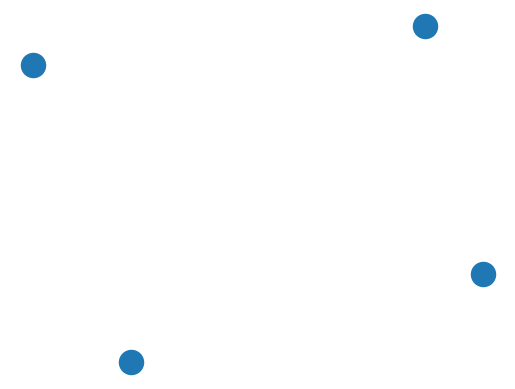

In [5]:
plt.subplots()
nx.draw(G)

In [6]:
def plot_graph(G, node_colour, edge_colour):
    plt.subplots(figsize=(8,8))
    ax = plt.gca()
    ax.margins(0.20)
    plt.axis('off')
    options = {
        'font_size': 24,
        'with_labels': True,
        'node_size': 1500,
        'node_color': node_colour,
        'edgecolors': edge_colour,
        'linewidths': 5,
        'width': 5,
    }
    
    nx.draw_shell(G, **options)

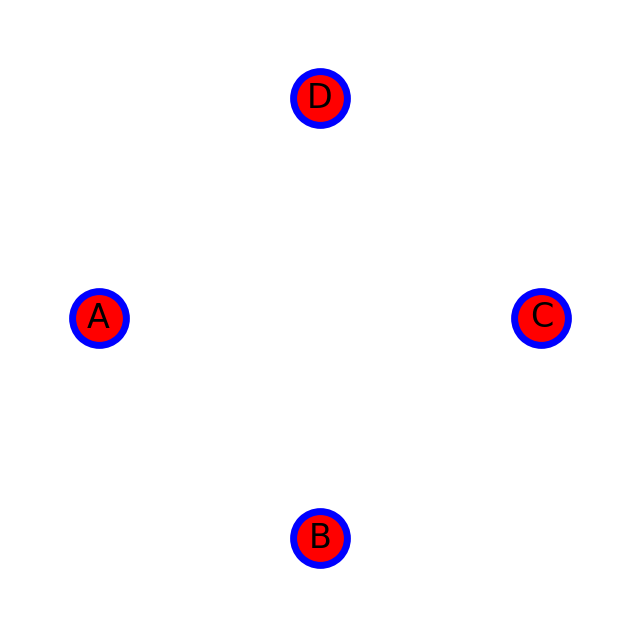

In [7]:
plot_graph(G, 'red', 'blue')

### Adding edges one at a time

In [8]:
G.add_edge('A', 'B')
G.add_edge('B', 'C')
G.add_edge('D', 'C')
G.add_edge('C', 'A')
G.nodes, G.edges

(NodeView(('A', 'B', 'C', 'D')),
 EdgeView([('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'D')]))

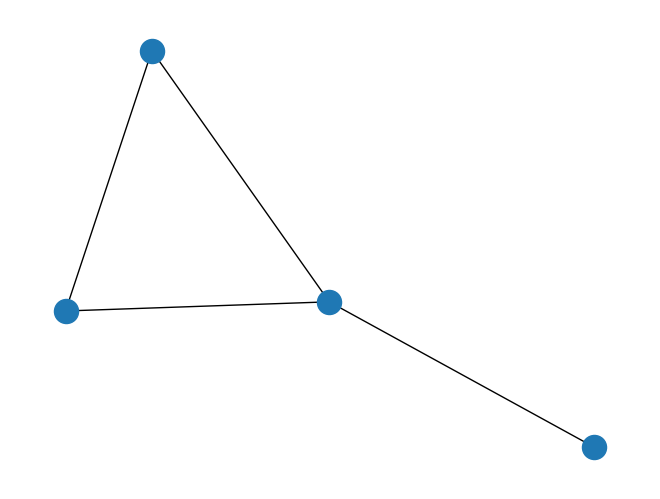

In [9]:
nx.draw(G)

### Graph Attributes

In [10]:
G.number_of_nodes(), G.number_of_edges()

(4, 4)

In [11]:
H = nx.Graph()
H.add_nodes_from(['W','X','Y','Z'])
H.add_edges_from([
    ('W','X'),
    ('W','Z'),
    ('W','Y'),
    ('X','Z'),
    ('X','Y')
])

### viewing nodes and edge sets

In [12]:
H.nodes, H.edges

(NodeView(('W', 'X', 'Y', 'Z')),
 EdgeView([('W', 'X'), ('W', 'Z'), ('W', 'Y'), ('X', 'Z'), ('X', 'Y')]))

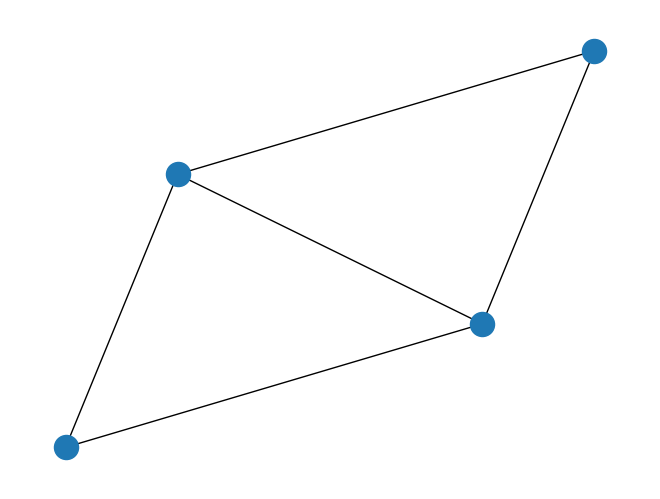

In [13]:
nx.draw(H)

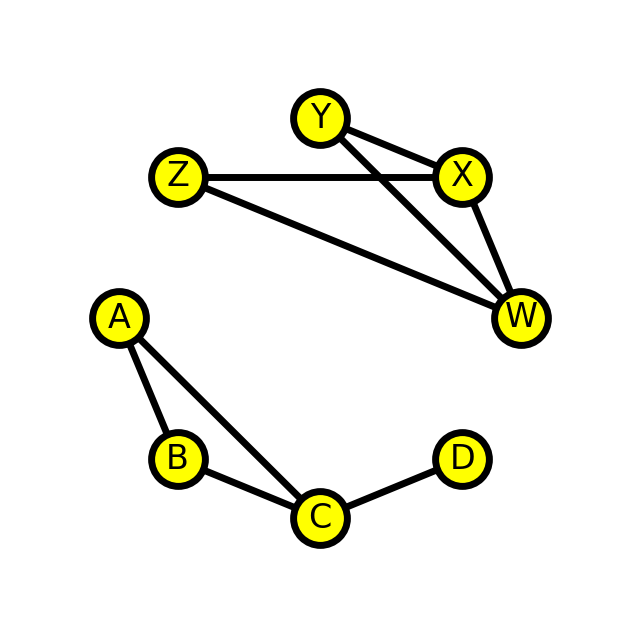

In [14]:
G.add_nodes_from(H.nodes)
G.add_edges_from(H.edges)
plot_graph(G, 'yellow', 'black')

### View Degree, adjacency

In [15]:
G.degree('D'), G.degree('B')

(1, 2)

In [16]:
G.adj['C']

AtlasView({'B': {}, 'D': {}, 'A': {}})

In [17]:
G.adj['A']

AtlasView({'B': {}, 'C': {}})

### Adding attributes

In [18]:
G.graph['logistics_network'] = 'Amamake'
G.add_node('Q', station='RSS')
G.nodes

NodeView(('A', 'B', 'C', 'D', 'W', 'X', 'Y', 'Z', 'Q'))

In [19]:
G.nodes['Q']

{'station': 'RSS'}

In [20]:
G.nodes.data()

NodeDataView({'A': {}, 'B': {}, 'C': {}, 'D': {}, 'W': {}, 'X': {}, 'Y': {}, 'Z': {}, 'Q': {'station': 'RSS'}})

In [21]:
G.nodes['A']['station'] = 'TTB'
G.nodes['B']['station'] = 'IFW'
G.nodes['C']['station'] = 'FL33T'

In [22]:
for data in G.nodes.data():
    print(data)

('A', {'station': 'TTB'})
('B', {'station': 'IFW'})
('C', {'station': 'FL33T'})
('D', {})
('W', {})
('X', {})
('Y', {})
('Z', {})
('Q', {'station': 'RSS'})


In [23]:
G.add_edge('Q', 'A', AU=8)


In [24]:
for d in G.edges.data():
    print(d)

('A', 'B', {})
('A', 'C', {})
('A', 'Q', {'AU': 8})
('B', 'C', {})
('C', 'D', {})
('W', 'X', {})
('W', 'Z', {})
('W', 'Y', {})
('X', 'Z', {})
('X', 'Y', {})


### Adding weights to edges

In [25]:
G.edges['A', 'B']['AU'] = 12
G.edges['A', 'C']['AU'] = 3
G.edges['C', 'D']['AU'] = 6
G.edges['Z', 'X']['AU'] = 5
G.edges['Z', 'W']['AU'] = 10
G.edges['Y', 'X']['AU'] = 8
G.edges['Y', 'W']['AU'] = 12
G.edges['B', 'C']['AU'] = 3
G.edges['W', 'X']['AU'] = 8

In [26]:
for station in G.edges.data():
    print(station)

('A', 'B', {'AU': 12})
('A', 'C', {'AU': 3})
('A', 'Q', {'AU': 8})
('B', 'C', {'AU': 3})
('C', 'D', {'AU': 6})
('W', 'X', {'AU': 8})
('W', 'Z', {'AU': 10})
('W', 'Y', {'AU': 12})
('X', 'Z', {'AU': 5})
('X', 'Y', {'AU': 8})


### Directed Graphs, adjacency, predecessor, in-out, degree

In [27]:
X = nx.DiGraph()
X.add_edges_from([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'C'),
    ('C', 'D')
])

X.edges['A', 'B']['AU'] = 12
X.edges['A', 'C']['AU'] = 3
X.edges['B', 'C']['AU'] = 6
X.edges['C', 'D']['AU'] = 5

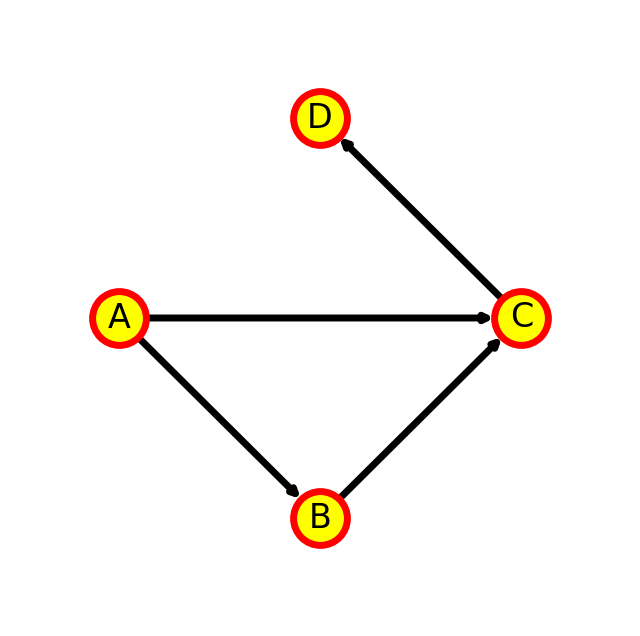

In [28]:
plot_graph(X, "yellow", 'red')

In [29]:
X.in_degree['C']

2

In [30]:
X.out_degree['B']

1

In [31]:
X.degree['B']

2

In [32]:
X.adj['D']

AtlasView({})

In [33]:
X.adj['C']

AtlasView({'D': {'AU': 5}})

In [34]:
X.adj['A']

AtlasView({'B': {'AU': 12}, 'C': {'AU': 3}})

In [35]:
X.out_edges

OutEdgeView([('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'D')])

In [36]:
X.in_edges

InEdgeView([('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'D')])

In [37]:
X.has_edge('A','B')

True

In [38]:
X.has_edge('B', 'D')

False

In [39]:
for n in X.successors('A'):
    print(n)

B
C


In [40]:
X.succ['A']

AtlasView({'B': {'AU': 12}, 'C': {'AU': 3}})

In [41]:
X.pred['C']

AtlasView({'A': {'AU': 3}, 'B': {'AU': 6}})

### Cycles and triangles

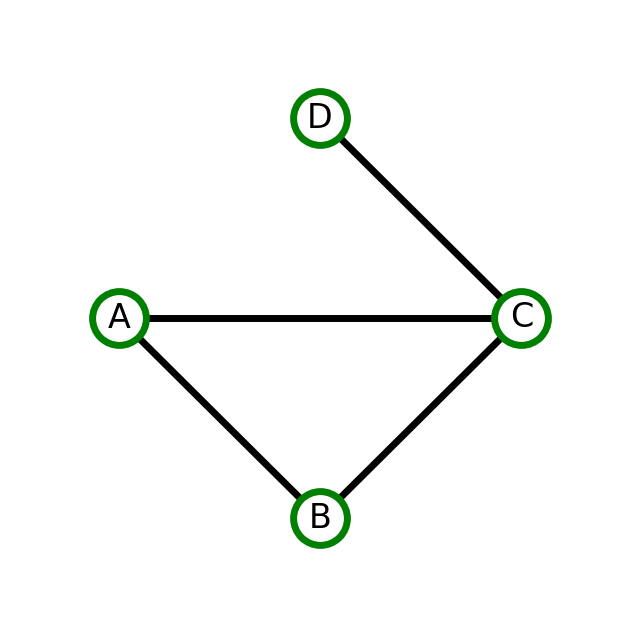

In [42]:
X2 = X.to_undirected()
plot_graph(X2, 'white', 'green')

In [43]:
list(nx.simple_cycles(G))

[['X', 'W', 'Z'], ['X', 'W', 'Y'], ['X', 'Z', 'W', 'Y'], ['A', 'B', 'C']]

In [44]:
list(nx.simple_cycles(X))

[]

In [45]:
list(nx.simple_cycles(X2))

[['A', 'B', 'C']]

In [46]:
list(nx.simple_cycles(H))

[['W', 'X', 'Z'], ['W', 'X', 'Y'], ['W', 'Z', 'X', 'Y']]

In [47]:
nx.triangles(X2) # how many triangles can each node be used in?

{'A': 1, 'B': 1, 'C': 1, 'D': 0}

In [48]:
nx.triangles(H)

{'W': 2, 'X': 2, 'Y': 1, 'Z': 1}

In [49]:
nx.min_edge_cover(H)

{('Y', 'X'), ('Z', 'W')}

### Computing the shortest path and minimum spanning tree

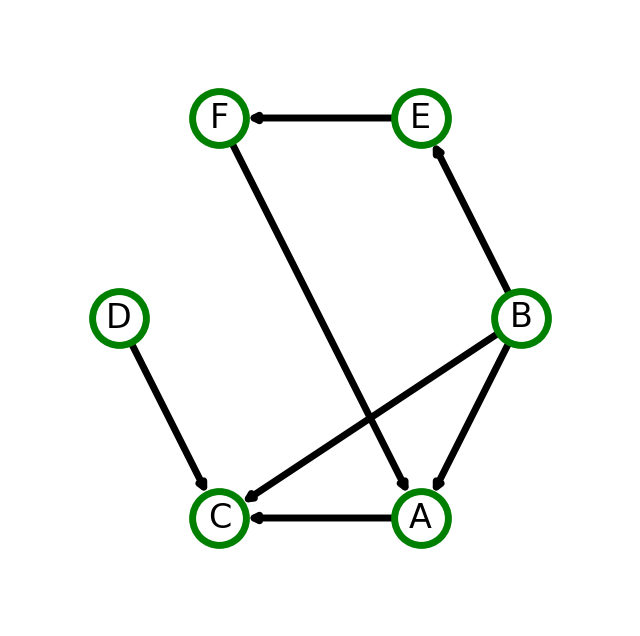

In [66]:
P = nx.DiGraph()
P.add_edges_from([
    ('D', 'C'),
    ('A', 'C'),
    ('B', 'A'),
    ('B', 'C'),
    ('B', 'E'),
    ('E', 'F'),
    ('F', 'A')
])
plot_graph(P, 'white', 'green')

In [67]:
list(nx.simple_cycles(P))

[]

In [68]:
nx.is_directed_acyclic_graph(P)

True

In [69]:
nx.ancestors(P, source='E')

{'B'}

In [70]:
nx.ancestors(P, source='A')

{'B', 'E', 'F'}

In [71]:
nx.ancestors(P, source='C')

{'A', 'B', 'D', 'E', 'F'}

In [73]:
nx.descendants(P, source='A')

{'C'}

In [74]:
nx.descendants(P, source='C')

set()

In [75]:
nx.descendants(P, source='E')

{'A', 'C', 'F'}

In [76]:
list(nx.topological_sort(P))

['D', 'B', 'E', 'F', 'A', 'C']

In [78]:
list(nx.all_topological_sorts(P))

[['B', 'E', 'F', 'A', 'D', 'C'],
 ['B', 'E', 'F', 'D', 'A', 'C'],
 ['B', 'E', 'D', 'F', 'A', 'C'],
 ['B', 'D', 'E', 'F', 'A', 'C'],
 ['D', 'B', 'E', 'F', 'A', 'C']]

In [79]:
nx.shortest_path(P, source='B', target='F')

['B', 'E', 'F']

In [80]:
nx.shortest_path(P, source='E', target='C')

['E', 'F', 'A', 'C']

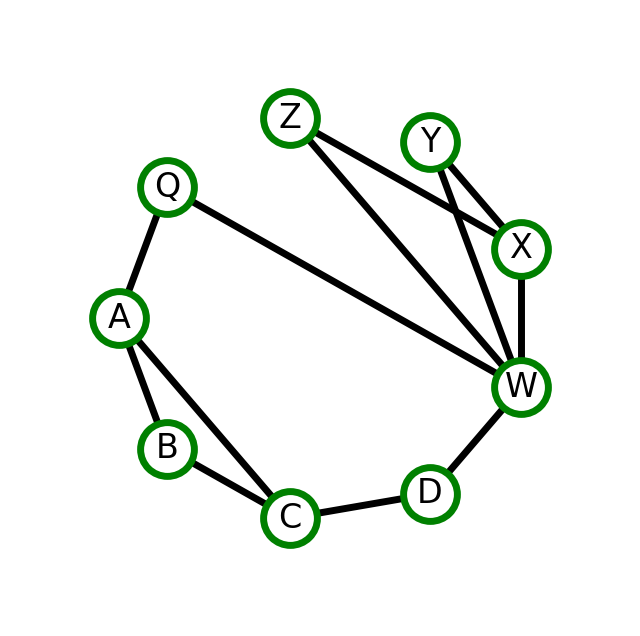

In [84]:
G.add_edge('D', 'W', AU=8)
G.add_edge('Q', 'W', AU=4)
plot_graph(G, 'white', 'green')

In [86]:
nx.shortest_path(G, source='A', target='Y', weight='AU')

['A', 'Q', 'W', 'Y']

In [87]:
nx.shortest_path(G, source='Y', target='B', weight='AU')

['Y', 'W', 'D', 'C', 'B']

In [88]:
MST = nx.minimum_spanning_tree(G)

In [89]:
list(MST)

['A', 'B', 'C', 'D', 'W', 'X', 'Y', 'Z', 'Q']

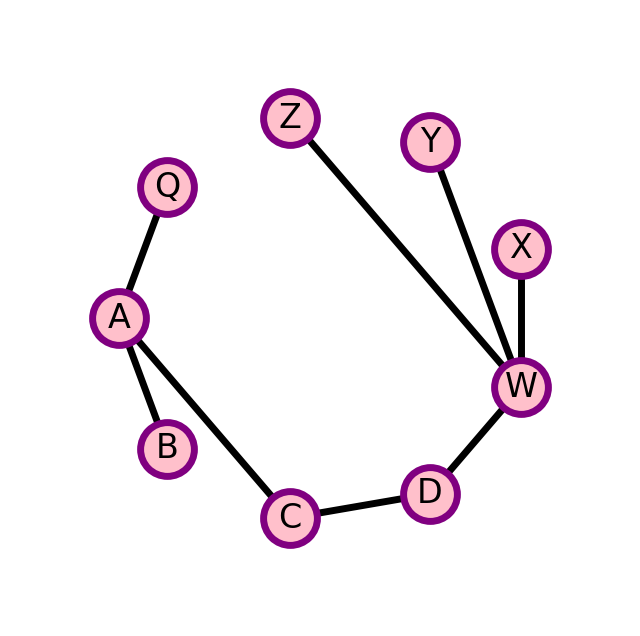

In [90]:
plot_graph(MST, 'pink', 'purple')

### Testing

In [92]:
T = nx.DiGraph()
T.add_edges_from([
    ('B','C'),
    ('B','E'),
    ('A','B')])

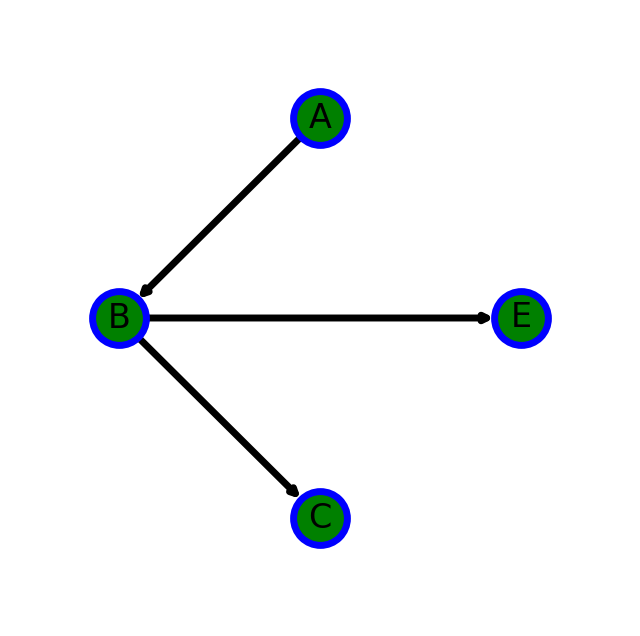

In [100]:
plot_graph(T, 'green', 'blue')

In [94]:
T.pred['E']

AtlasView({'B': {}})

In [97]:
T.succ['B']

AtlasView({'C': {}, 'E': {}})

In [98]:
T.pred['B']

AtlasView({'A': {}})

In [101]:
T.degree('B')

3

In [102]:
T2 = nx.DiGraph()
T2.add_edges_from([
    ('A','B'),
    ('B','D'),
    ('D','C'),
    ('D','E')])

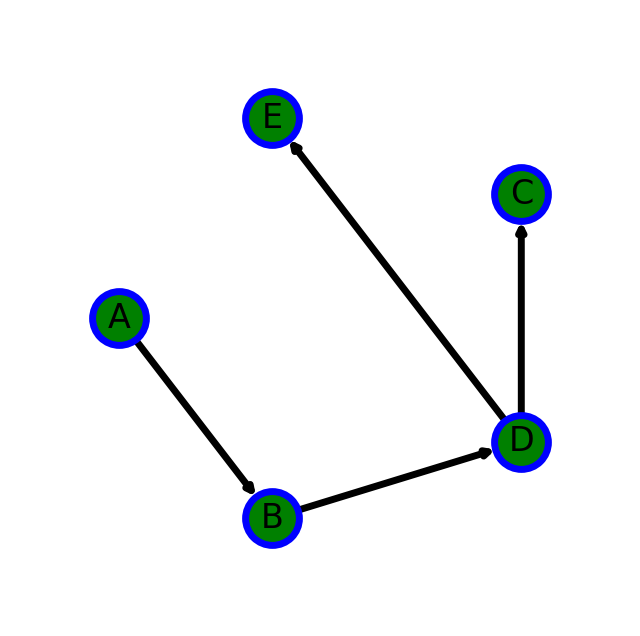

In [103]:
plot_graph(T2, 'green', 'blue')

In [104]:
nx.ancestors(T2, source='D')

{'A', 'B'}